In [1]:
import gzip
import sys,os
import pandas as pd
import allel
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
os.chdir("/Users/evolutioneco/Project/3.SV/4.localPCA/male_genome/Aripo/vcf/")
callset = allel.read_vcf('Aripo.LG6.vcf.gz')

/Users/evolutioneco/anaconda3/lib/python3.10/site-packages/allel/io/vcf_read.py:1732: UserWarning: invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'
  warnings.warn('invalid INFO header: %r' % header)


In [3]:
callset['variants/CHROM']

array(['LR880650.1', 'LR880650.1', 'LR880650.1', ..., 'LR880650.1',
       'LR880650.1', 'LR880650.1'], dtype=object)

In [20]:
#chrom = "LR880645.1" # chromosome 1
chrom = callset['variants/CHROM'][0] #"LR880660.1" # chromosome 4
start = 4000000
end = 5000000
callset = allel.read_vcf('Aripo.LG6.vcf.gz', region="{}:{}-{}".format(chrom, start, end))

/Users/evolutioneco/anaconda3/lib/python3.10/site-packages/allel/io/vcf_read.py:1732: UserWarning: invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'
  warnings.warn('invalid INFO header: %r' % header)


In [27]:
# genotype 
g = allel.GenotypeArray(callset['calldata/GT'])
ac = g.count_alleles()[:]
# SNP filtering
flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)
gf = g.compress(flt, axis=0)
gn = gf.to_n_alt()
# PCA 
coords1, model1 = allel.pca(gn, n_components=10, scaler='patterson')

# calculate heterozygosity 
sample_list = []
for i in range(len(callset['samples'])):
    het_count = g[:,i].count_het()
    prop_het_sample = het_count*100 / (end - start)
    sample_list.append([callset['samples'][i], coords1[i][0], coords1[i][1], prop_het_sample])
df = pd.DataFrame(sample_list, columns=["samples",
                                        "PC1", "PC2", "hetero"])
#### clustering 
X = df[['PC1']]

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
df_cl = X.copy()
# add one more column
df_cl['cluster'] = kmeans.predict(X)
df["cluster"] = kmeans.predict(X)
#df["sex"] = ["M"]*10 + ['F'] *10
df["sex"] = ["F"]*10 +  ['M'] *10 + ["F"]*10 +  ['M'] *10
#df["sex"] = ["F"]*10 + ['M'] *9 
df['pop'] = ['ARH'] * 20 + ['ARL'] * 20
#df['pop'] =  ['QUH'] * 19
# sort by PC1 
sort_df = df.sort_values(by=["cluster","PC2"])
sort_df

/Users/evolutioneco/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,samples,PC1,PC2,hetero,cluster,sex,pop
30,ArL-M11,51.881802,-162.994659,0.4395,0,M,ARL
25,ArL-F20,51.209221,-162.523575,0.4339,0,F,ARL
23,ArL-F18,51.669502,-161.819397,0.4478,0,F,ARL
20,ArL-F10,50.414421,-160.926361,0.4432,0,F,ARL
4,ArH-F1,40.029362,-66.639420,0.3418,0,F,ARH
38,ARL-M25,40.742607,5.825639,0.2602,0,M,ARL
34,ARL-M17,40.107246,9.357780,0.2069,0,M,ARL
26,ArL-F22,38.974678,10.192770,0.2296,0,F,ARL
12,ArH-M19,38.190388,13.193139,0.2354,0,M,ARH
3,ArH-F14,34.651134,20.794857,0.2207,0,F,ARH


In [28]:
total_list = []
for i in callset['calldata/GT']:
    tmp_list = []
    for x in i:
        tmp_list.append(sum(x))
    total_list.append(tmp_list)
total_list = np.array(total_list)

In [29]:
total_list_sort = []
for i in sort_df.index:
    total_list_sort.append(total_list[:,i])
total_list_sort = np.array(total_list_sort)

Text(0, 0.5, 'Samples')

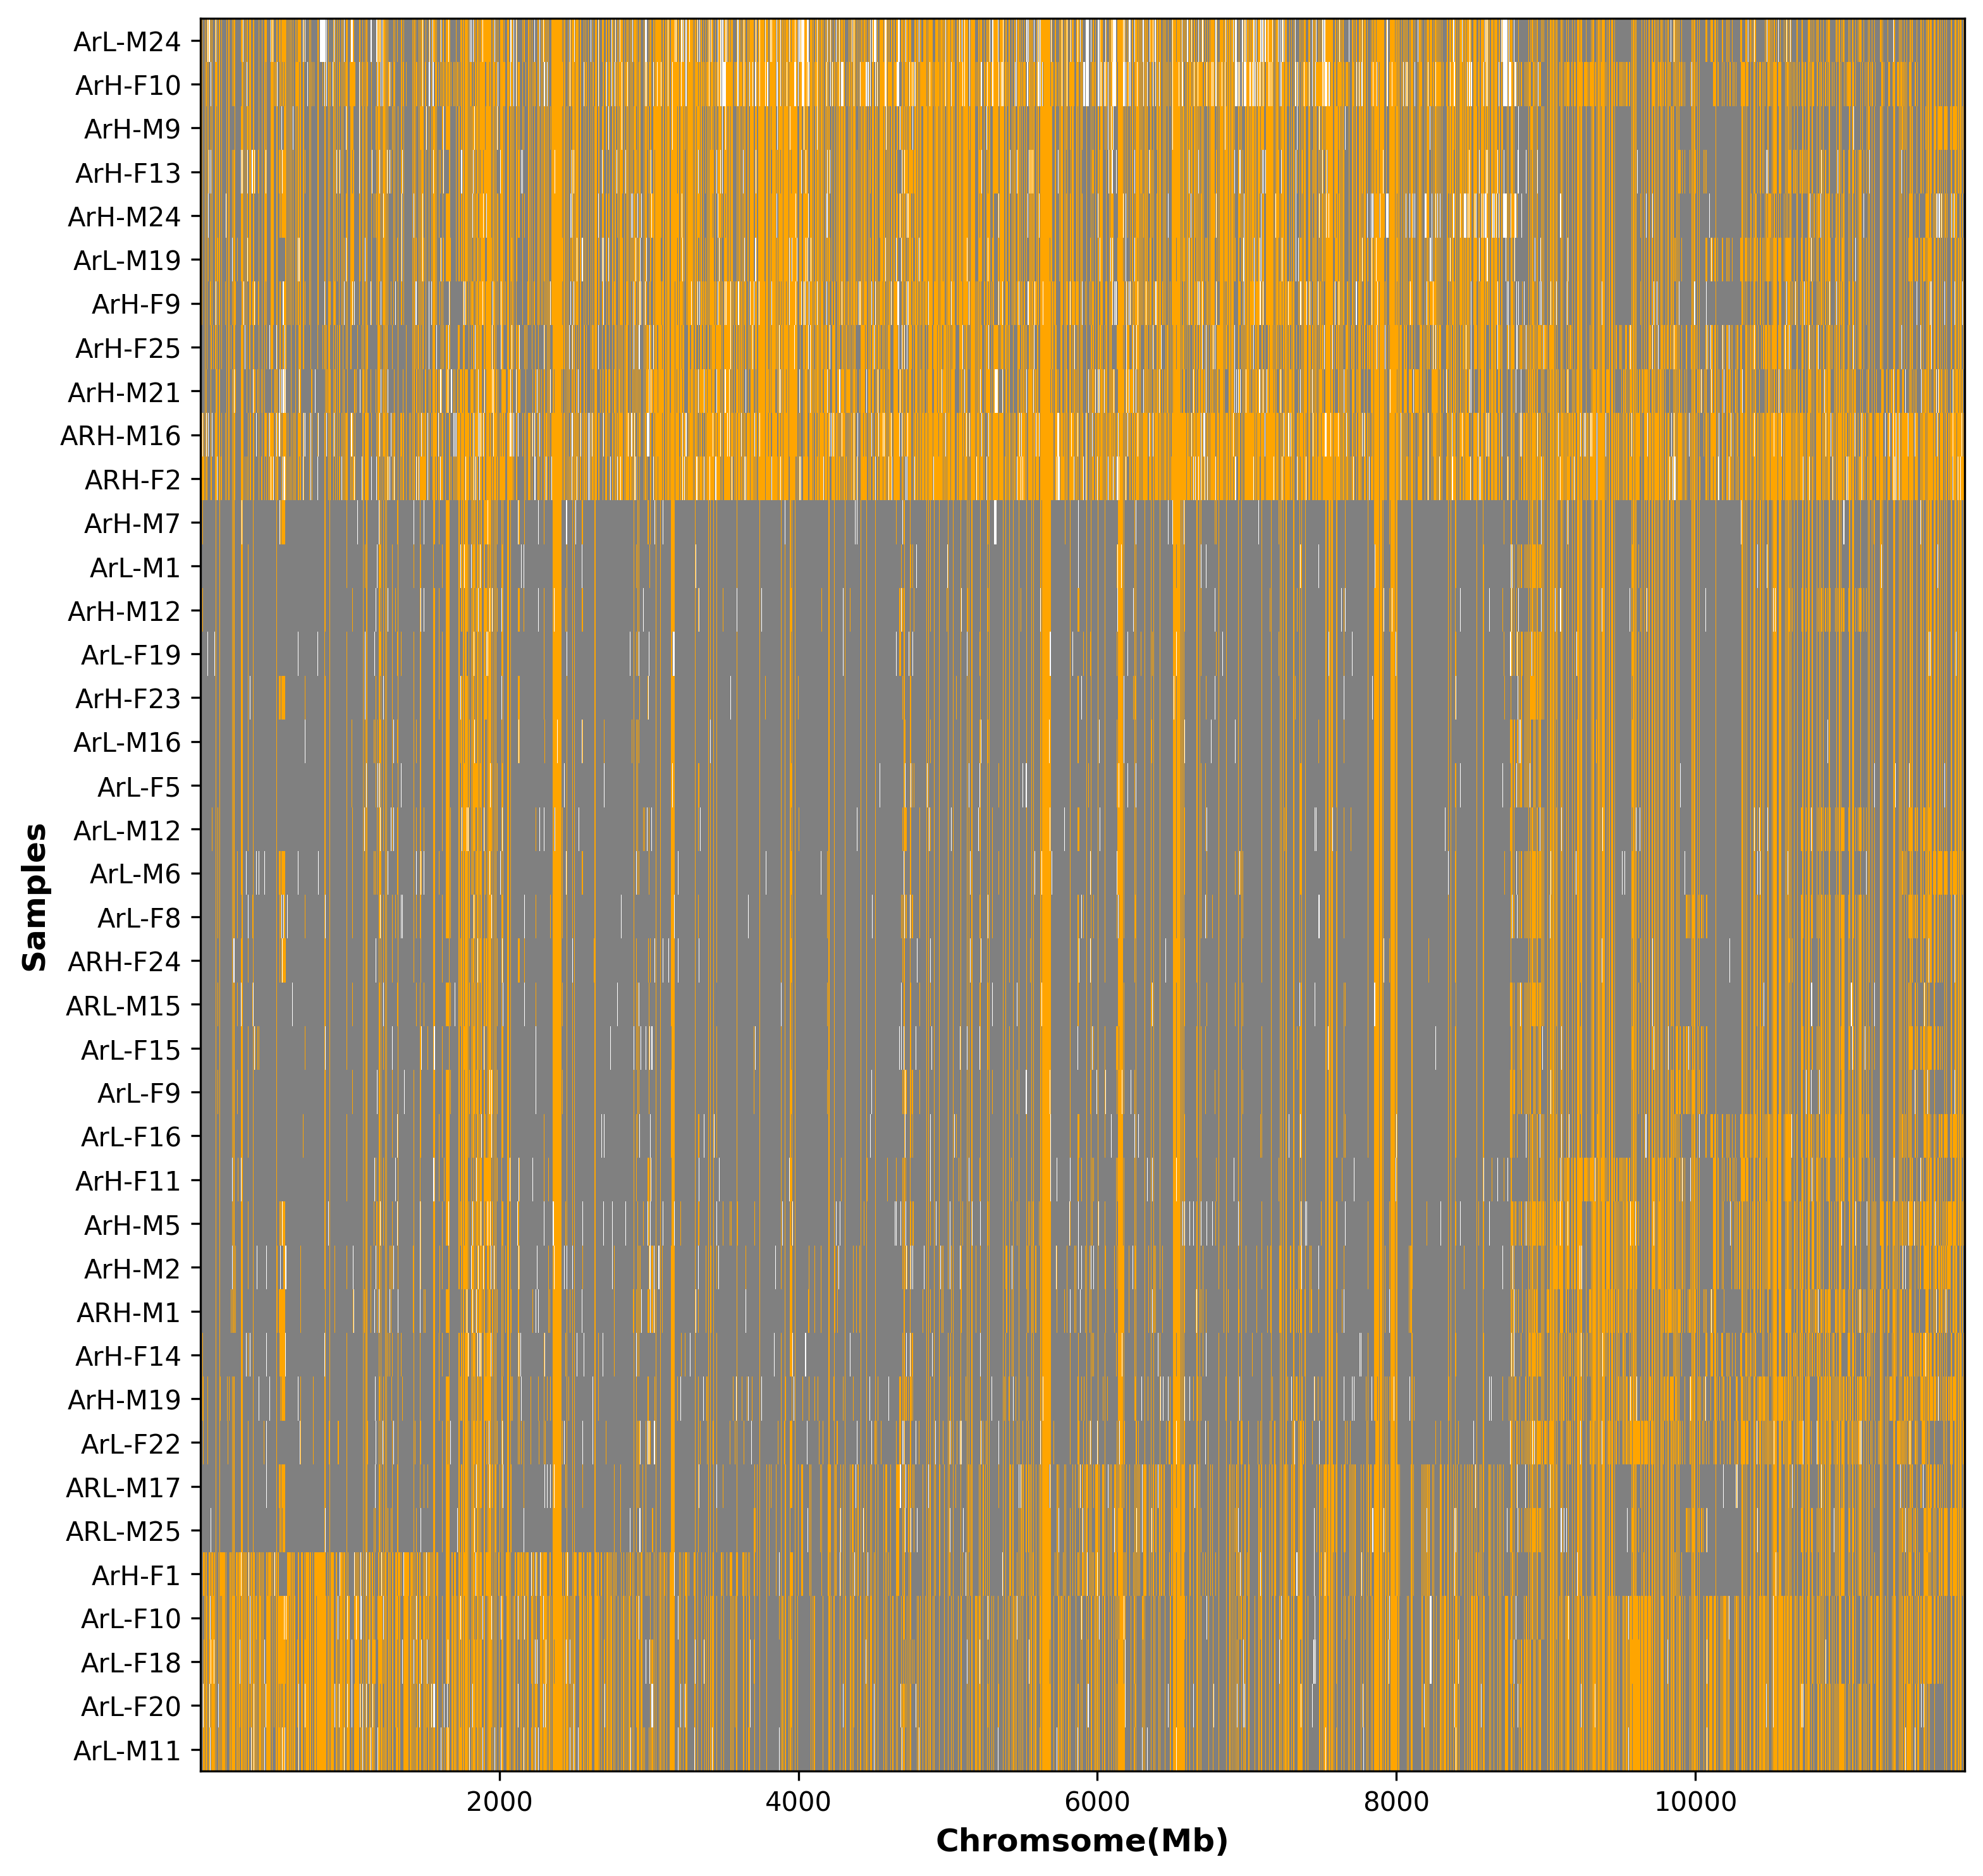

In [30]:
y = np.arange(1, total_list_sort.shape[0] + 1, 1)  # len = 39
x = np.arange(1, total_list_sort.shape[1] + 1, 1)   # len = 100
cmap = mpl.colors.ListedColormap([
    'white',       # -2, missing
    'green',       # 0, [0,0]
    "grey",       # 1, [0,1] heterozygosity
    'orange',      # 2, [1,1]
])
fig, ax = plt.subplots(figsize=(12, .3 * total_list_sort.shape[0]), dpi=300)
ax.pcolormesh(x, y, total_list_sort, cmap =cmap)
# ax.pcolormesh(genotypeLen, samplesSize, Z=genotype color)
ax.set_yticks(np.arange(1, total_list_sort.shape[0] + 1, 1))
#ax.set_xticks(np.arange(0, 22500, 2500))
#ax.set_xticklabels(np.arange(0, 2.2500, 0.2500))
ax.set_yticklabels(list(sort_df["samples"]))
ax.set_xlabel("Chromsome(Mb)", fontweight="bold", fontsize = 12)
ax.set_ylabel("Samples", fontweight="bold", fontsize = 12)

#DA9B4F
#7794C3
#A3B18A


Text(0, 0.5, 'Samples')

<Figure size 3200x2400 with 0 Axes>

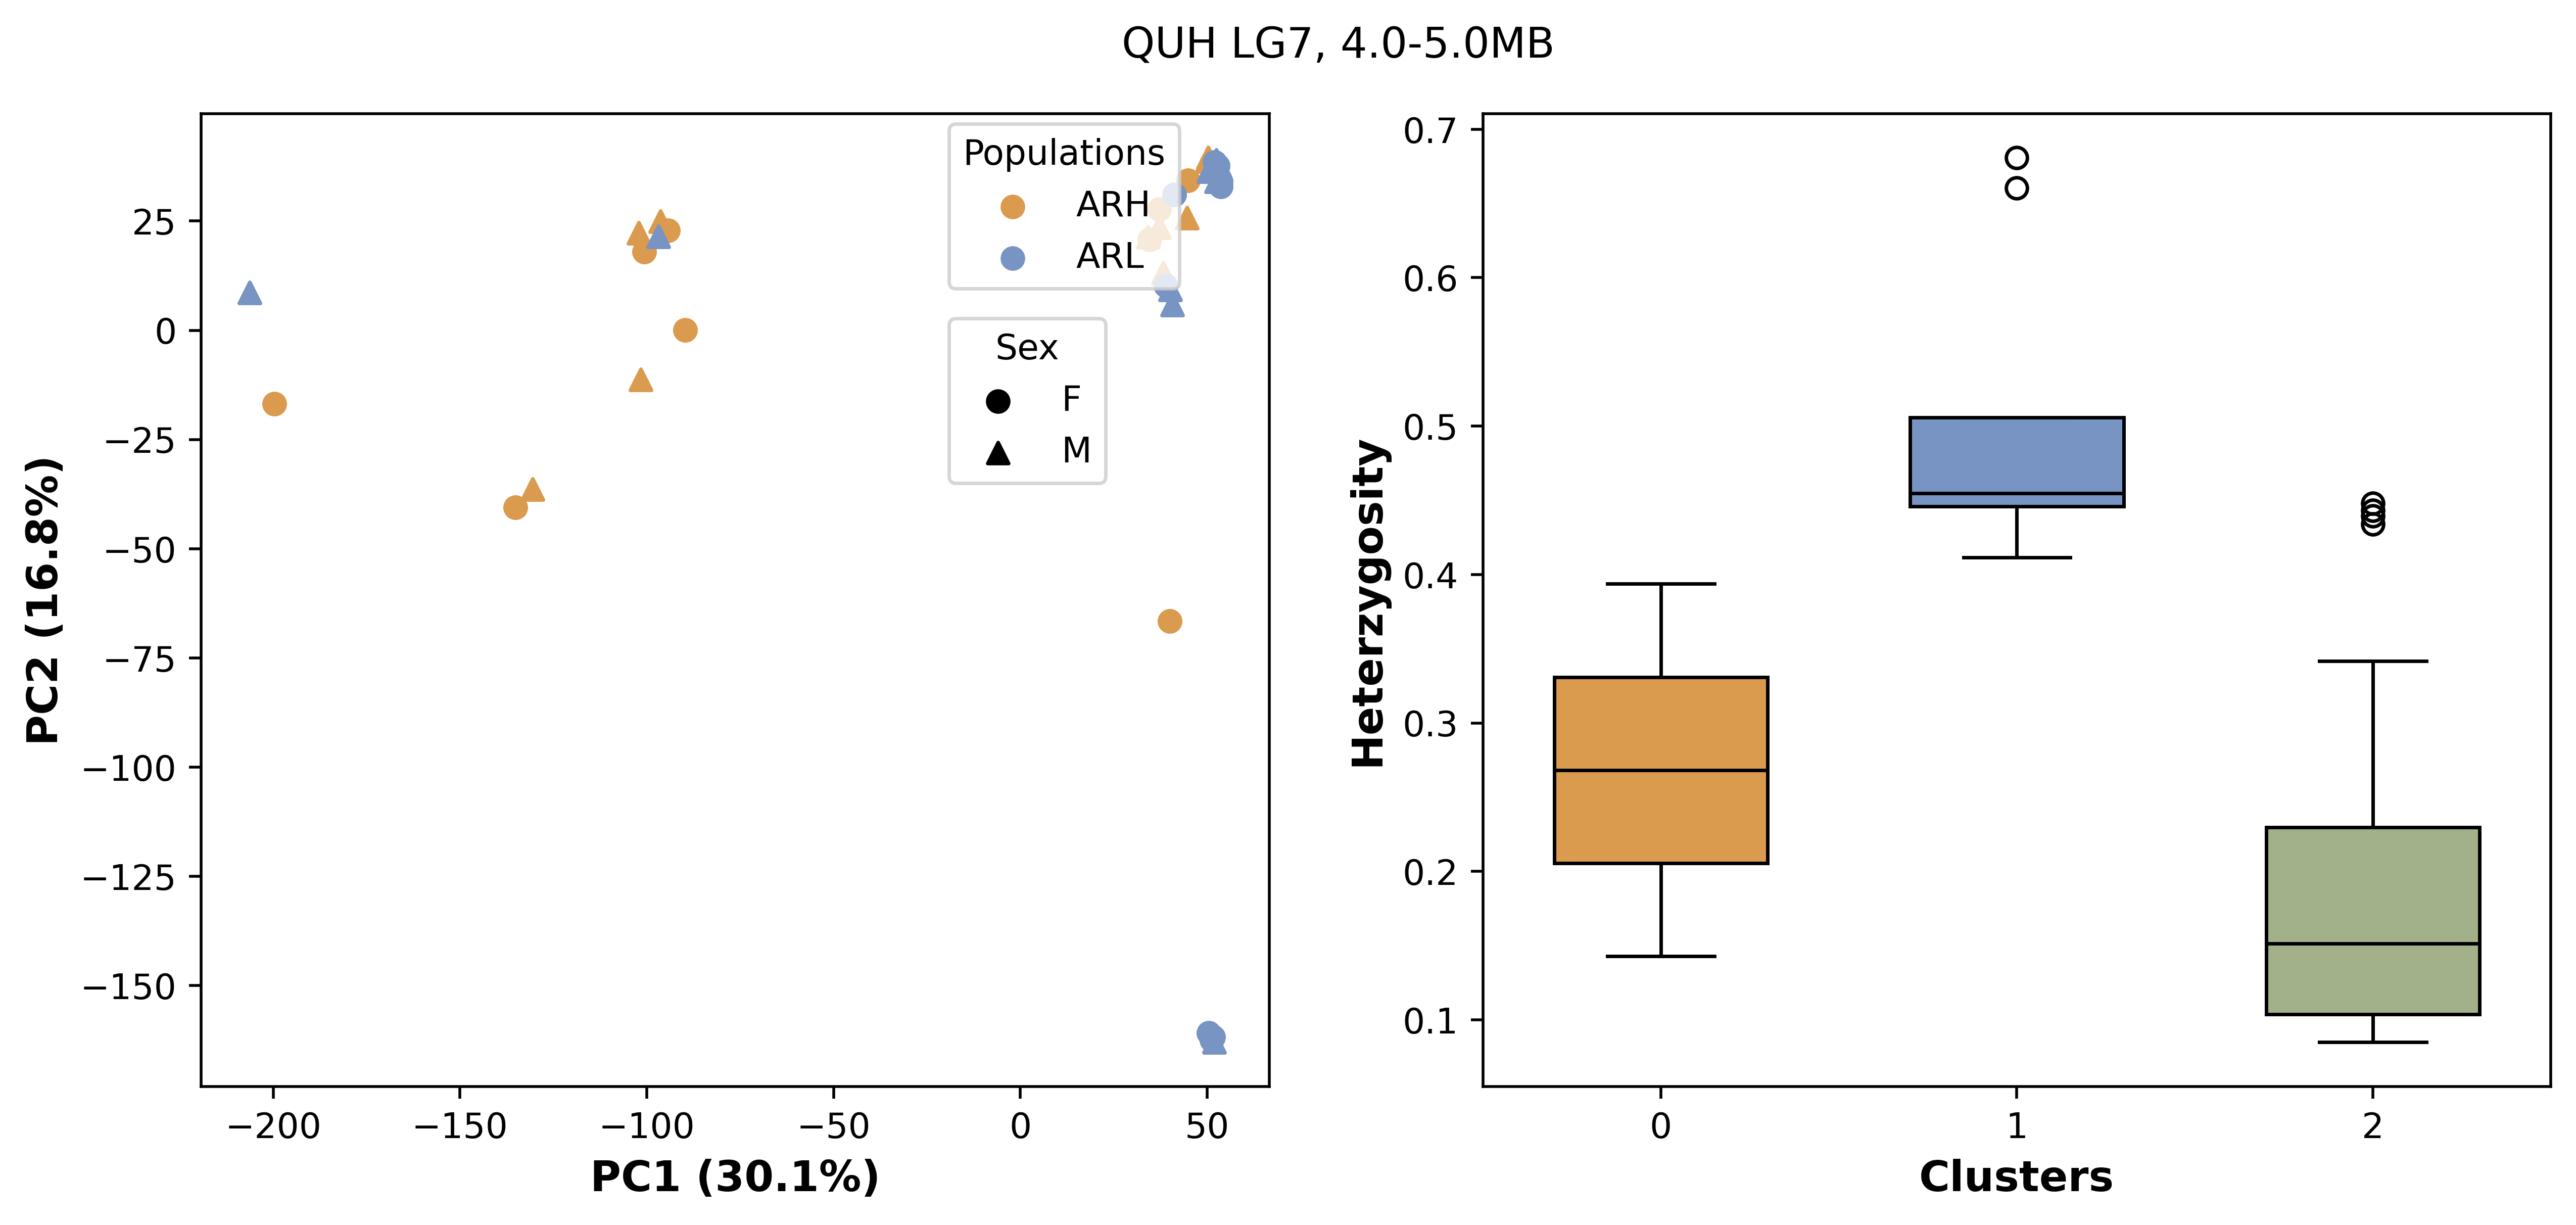

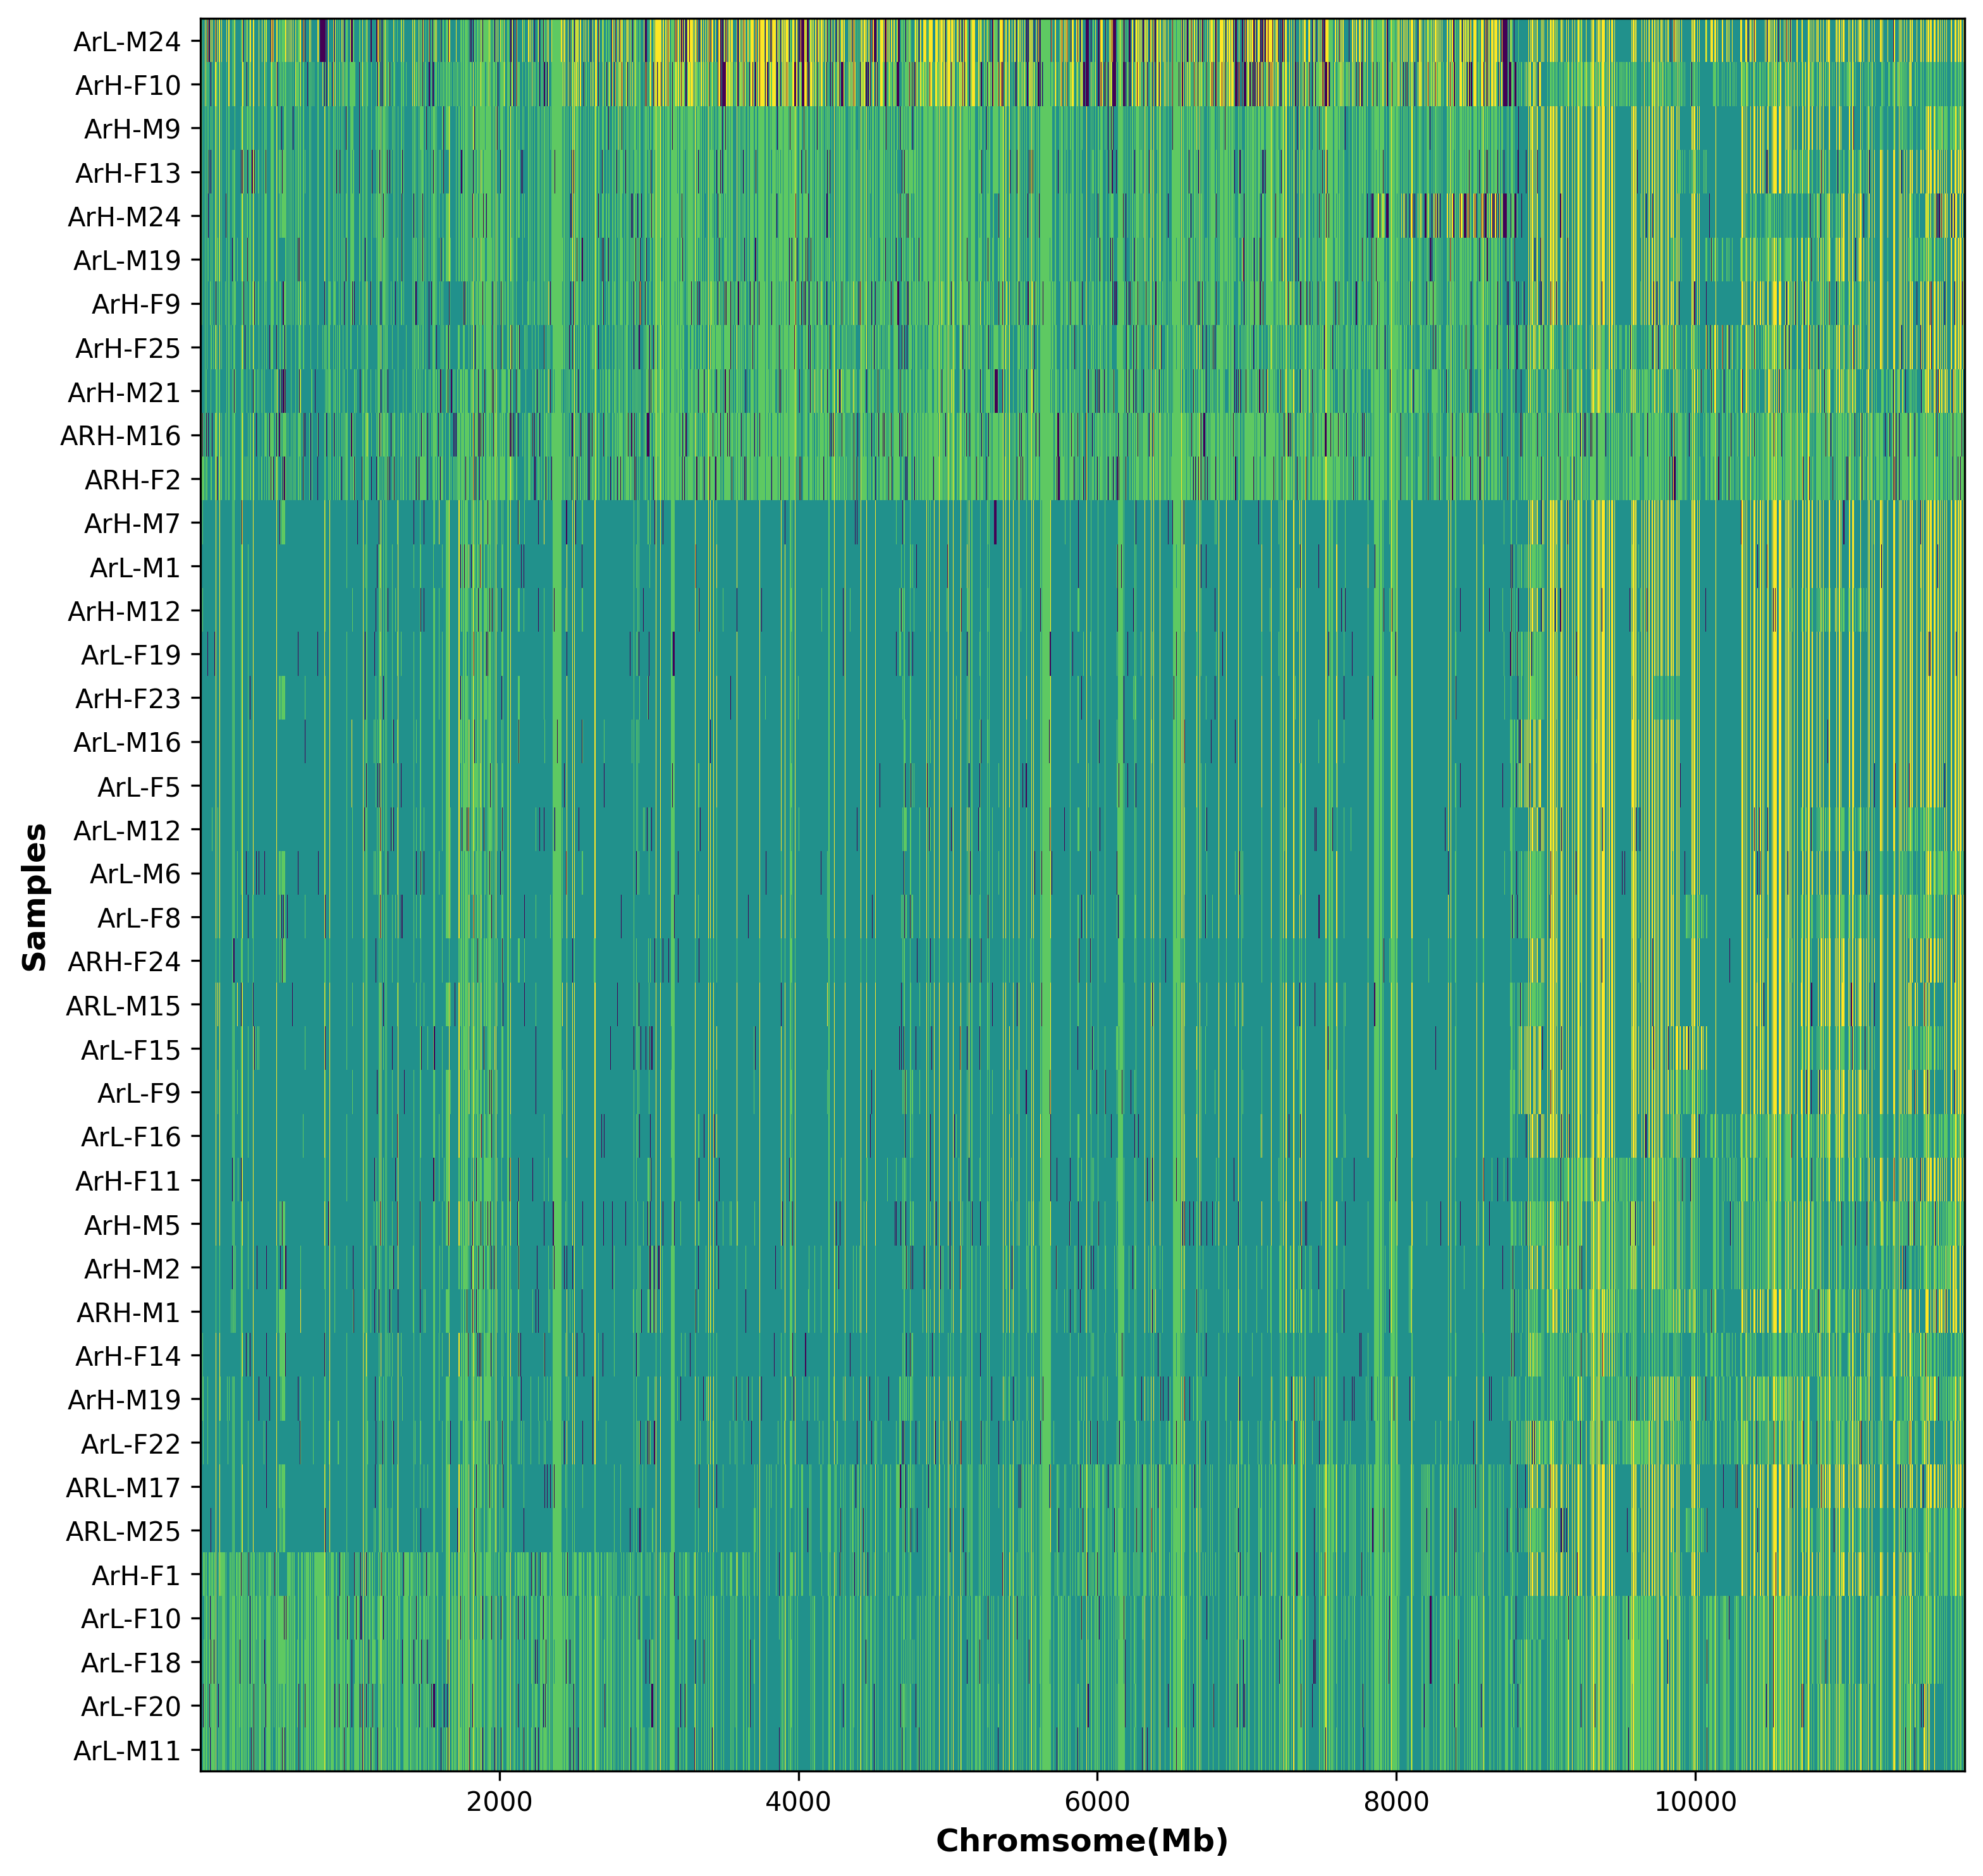

In [31]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.figure(dpi = 500)
# plt.title("LG12, 2-3.5MB")
fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi = 500)
fig.suptitle("QUH LG7, {}-{}MB".format(str(int(start)/1000000), str(int(end)/1000000)), y=0.95)

# Read data into a pandas dataframe

#cluster_colors = {'0':'#DA9B4F', '1':'#7794C3', '2':'#A3B18A'}
sex = {"F":"o", "M":"^"}
pop_colors = {"ARH": "#DA9B4F", "ARL": '#7794C3'}
#pop_colors = {'QUH':'grey', 'QUL':'orange'}
#pop_colors = {'0':'#DA9B4F', '1':'#7794C3', '2':'#A3B18A'}
# Plot the clusters
for pop in pop_colors.keys():
    for s in sex.keys():
        subset = sort_df[(sort_df['pop'] == pop) & (sort_df['sex'] == s)]
        axs[0].scatter(subset['PC1'], subset['PC2'], color=pop_colors[pop],
                       marker=sex[s], label=f'{pop}')
        axs[0].scatter(subset['PC1'], subset['PC2'], color=pop_colors[pop],
                       marker=sex[s], label=f'{s}')
        
##### previous 
# for pop in cluster_colors.keys():
#     for s in sex.keys():
#         subset = df[(df['cluster'] == int(pop)) & (df['sex'] == s)]
#         axs[0].scatter(subset['PC1'], subset['PC2'], color=cluster_colors[pop],
#                        marker=sex_markers[s], label=f'{pop}')
#         axs[0].scatter(subset['PC1'], subset['PC2'], color=cluster_colors[pop],
#                        marker=sex_markers[s], label=f'{s}')
        
# # Add legend for population
handles, labels = [], []
for pop in pop_colors.keys():
    handles.append(plt.scatter([], [], color=pop_colors[pop], marker='o'))
    labels.append(pop)
first_legend = axs[0].legend(handles, labels, title='Populations', loc=[0.70, 0.82])
axs[0].add_artist(first_legend)

# Add legend for sex
handles, labels = [], []
for s in sex.keys():
    handles.append(plt.scatter([], [], color='black', marker=sex[s]))
    labels.append(s)
axs[0].legend(handles, labels, title='Sex', loc=[0.70, 0.62])

# lables
pc1=0
pc2=1

axs[0].set_xlabel(('PC%s (%.1f%%)' % (pc1+1, model1.explained_variance_ratio_[pc1]*100)), fontsize=12, fontweight="bold")
axs[0].set_ylabel(('PC%s (%.1f%%)' % (pc2+1, model1.explained_variance_ratio_[pc2]*100)), fontsize=12, fontweight="bold")



# Fig 2.1 Define the colors

# plot violin plot for cluster 0
# plot violin plot for cluster 1
# plot violin plot for cluster 0
bplot1 = axs[1].boxplot(sort_df.loc[sort_df["cluster"] == 2, "hetero"], positions=[0], widths=0.6,
                        patch_artist=True,  medianprops=dict(color="black"))
bplot2 = axs[1].boxplot(sort_df.loc[sort_df["cluster"] == 1, "hetero"], positions=[1], widths=0.6,
                        patch_artist=True,  medianprops=dict(color="black"))


bplot3 = axs[1].boxplot(sort_df.loc[sort_df["cluster"] == 0, "hetero"], positions=[2], widths=0.6, 
                        patch_artist=True, medianprops=dict(color="black"))



              
colors = ['#DA9B4F', '#7794C3', '#A3B18A']
#colors = ['#DA9B4F', '#7794C3']
# Set the facecolor for each box
for bplot, color in zip([bplot1, bplot2, bplot3], colors):
    for patch in bplot['boxes']:
        print(color)
        patch.set_color(color)
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
axs[1].set_xticklabels(["0", "1", "2"])

axs[1].set_xlabel("Clusters", fontsize=12, fontweight="bold")
axs[1].set_ylabel("Heterzygosity", fontsize=12, fontweight="bold")

y = np.arange(1, total_list_sort.shape[0] + 1, 1)  # len = 39
x = np.arange(1, total_list_sort.shape[1] + 1, 1)   # len = 100
cmap = mpl.colors.ListedColormap([
    'white',       # -2, missing
    'green',       # 0, [0,0]
    "grey",       # 1, [0,1] heterozygosity
    'orange',      # 2, [1,1]
])
fig, ax = plt.subplots(figsize=(12, .3 * total_list_sort.shape[0]), dpi=300)
#ax.pcolormesh(x, y, total_list_sort, cmap =cmap)
ax.pcolormesh(x, y, total_list_sort)
# ax.pcolormesh(genotypeLen, samplesSize, Z=genotype color)
ax.set_yticks(np.arange(1, total_list_sort.shape[0] + 1, 1))
#ax.set_xticks(np.arange(0, 22500, 2500))
#ax.set_xticklabels(np.arange(0, 2.2500, 0.2500))
ax.set_yticklabels(list(sort_df["samples"]))
ax.set_xlabel("Chromsome(Mb)", fontweight="bold", fontsize = 12)
ax.set_ylabel("Samples", fontweight="bold", fontsize = 12)

In [61]:
?ax.pcolormesh

Signature:
ax.pcolormesh(
    *args,
    alpha=None,
    norm=None,
    cmap=None,
    vmin=None,
    vmax=None,
    shading=None,
    antialiased=False,
    data=None,
    **kwargs,
)
Docstring:
Create a pseudocolor plot with a non-regular rectangular grid.

Call signature::

    pcolormesh([X, Y,] C, **kwargs)

*X* and *Y* can be used to specify the corners of the quadrilaterals.

.. hint::

   `~.Axes.pcolormesh` is similar to `~.Axes.pcolor`. It is much faster
   and preferred in most cases. For a detailed discussion on the
   differences see :ref:`Differences between pcolor() and pcolormesh()
   <differences-pcolor-pcolormesh>`.

Parameters
----------
C : array-like
    The mesh data. Supported array shapes are:

    - (M, N) or M*N: a mesh with scalar data. The values are mapped to
      colors using normalization and a colormap. See parameters *norm*,
      *cmap*, *vmin*, *vmax*.
    - (M, N, 3): an image with RGB values (0-1 float or 0-255 int).
    - (M, N, 4): an image with 

# interpopulation Fst

In [39]:
genotype_all = allel.GenotypeChunkedArray(callset['calldata/GT'])

In [40]:
df_samples = pd.read_csv("/Users/rainlam/localPCA/Quare.pop", sep="\t")

In [43]:
df_samples.head()
pop1 = 'QuH'
pop2 = 'QuL'
n_samples_pop1 = np.count_nonzero(df_samples.population == pop1)
n_samples_pop2 = np.count_nonzero(df_samples.population == pop2)
print(pop1, n_samples_pop1, pop2, n_samples_pop2)

QuH 19 QuL 20
